Размер KA: (805, 156)
Размер KD: (1173, 156)

Метки в KA (уникальные): [0 1]
Метки в KD (уникальные): [0 1]
Размер после очистки KA: (805, 132)
Размер после очистки KD: (1173, 133)

Общий датасет размером: (1978, 133)

Количество NaN в X до разбивки: 23569
Train: (1384, 131), Val: (198, 131), Test: (396, 131)

Колонки с NaN в train: 37
Примеры: ['elaboration_NS', 'interpretation-evaluation_SN', 'joint_NN', 'background_NS', 'restatement_NN']
Количество NaN: 17131

После импутации: NaN в train = 0

Классы в train: {0: 421, 1: 963}
Используем k_neighbors=3 для SMOTE


C:\Soft\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Не удается найти указанный файл
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Soft\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Soft\Anaconda\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Soft\Anaconda\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Soft\Anaconda\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^

После SMOTE: {0: 963, 1: 963}

=== СТАТИСТИКА ===
Всего примеров: 1978
Тревожность (1/0): {1: 432, 0: 373}
Депрессия (1/0): {1: 944, 0: 229}

Топ-20 коррелирующих признаков (abs, на оригинальных train данных):
unique_words_rate             0.144784
tgw_bodily_states_emotions    0.139612
sentiment_rate                0.136530
postag_APRO                   0.135813
ew_negative                   0.115230
be_fear                       0.112958
condition_NS                  0.110190
average_edu_length            0.107713
pro_1p_plural_rate            0.106833
solutionhood_SN               0.105362
comparison_NN                 0.103078
condition_SN                  0.103076
max_synt_tree                 0.102281
attribution_SN                0.102231
det                           0.100530
acl:relcl                     0.095166
average_du_length             0.088310
postag_ADV                    0.087446
tgw_affect_lex                0.086332
purpose_NS                    0.082362

Паспорт д

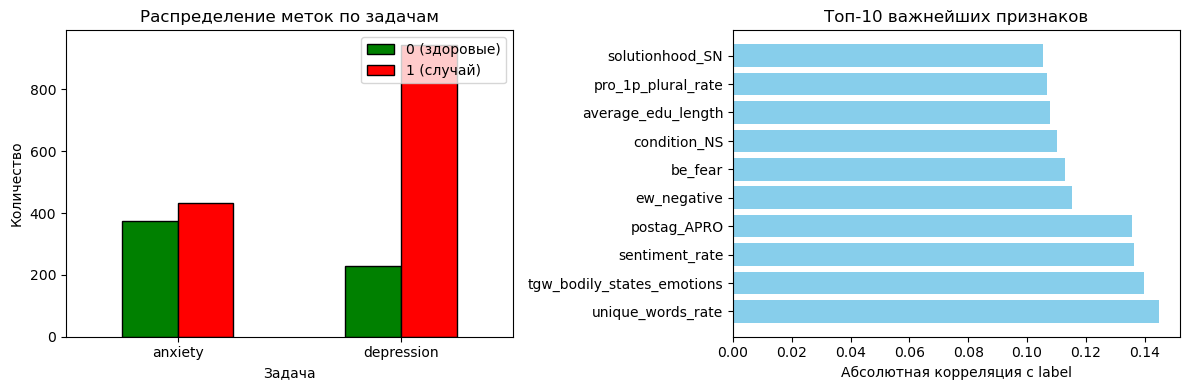


Графики сохранены в data_analysis.png


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. ЗАГРУЗКА
# ===============================
df_ka = pd.read_csv('data/KA.csv', index_col=0)
df_kd = pd.read_csv('data/KD.csv', index_col=0)

print("Размер KA:", df_ka.shape)
print("Размер KD:", df_kd.shape)

# ===============================
# 2. ПРОВЕРКА МЕТОК (уже числовые)
# ===============================
print("\nМетки в KA (уникальные):", df_ka['label'].unique())
print("Метки в KD (уникальные):", df_kd['label'].unique())

# ===============================
# 3. УДАЛЕНИЕ ШУМА
# ===============================
noise_features = [
    'ID', 'group', 'text',
    'flat:foreign:', 'goeswith', 'list', 'orphan',
    'punctuation_per_word', 'uppercase_rate',
    'be_calm_excitement', 'be_happyness', 'be_wonder',
    'tgw_security_structures', 'tgw_economics', 'tgw_catastrophes',
    'tgw_hcs', 'tgw_positive_assessment', 'tgw_positive_social', 'tgw_positive_emotions',
    'ew_positive',
    'number_of_trees', 'first_tree_edus_number'
]

for feat in noise_features:
    if feat in df_ka.columns:
        df_ka.drop(columns=[feat], inplace=True)
    if feat in df_kd.columns:
        df_kd.drop(columns=[feat], inplace=True)

# Удаляем колонки с нулевой дисперсией (константные)
df_ka = df_ka.loc[:, (df_ka.nunique() > 1)]
df_kd = df_kd.loc[:, (df_kd.nunique() > 1)]

print("Размер после очистки KA:", df_ka.shape)
print("Размер после очистки KD:", df_kd.shape)

# ===============================
# 4. ОБЪЕДИНЕНИЕ
# ===============================
df_ka['task'] = 'anxiety'
df_kd['task'] = 'depression'

common_cols = list(set(df_ka.columns) & set(df_kd.columns))
df_ka = df_ka[common_cols]
df_kd = df_kd[common_cols]

df_combined = pd.concat([df_ka, df_kd], axis=0, ignore_index=True)
print("\nОбщий датасет размером:", df_combined.shape)

# ===============================
# 5. РАЗБИВКА
# ===============================
X = df_combined.drop(columns=['label', 'task'])
y = df_combined['label']
task = df_combined['task']

# Проверка на NaN перед разбивкой
print(f"\nКоличество NaN в X до разбивки: {X.isnull().sum().sum()}")

X_temp, X_test, y_temp, y_test, task_temp, task_test = train_test_split(
    X, y, task, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val, task_train, task_val = train_test_split(
    X_temp, y_temp, task_temp, test_size=0.125, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# ===============================
# 6. ОБРАБОТКА ПРОПУСКОВ
# ===============================
# Проверяем NaN в train
nan_counts = X_train.isnull().sum()
nan_cols = nan_counts[nan_counts > 0].index.tolist()
print(f"\nКолонки с NaN в train: {len(nan_cols)}")
if len(nan_cols) > 0:
    print(f"Примеры: {nan_cols[:5]}")
    print(f"Количество NaN: {X_train[nan_cols].isnull().sum().sum()}")

# Импутация медианой (устойчива к выбросам)
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val_imputed = pd.DataFrame(
    imputer.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"\nПосле импутации: NaN в train = {X_train_imputed.isnull().sum().sum()}")

# ===============================
# 7. АУГМЕНТАЦИЯ (SMOTE)
# ===============================
# Проверяем, можно ли применять SMOTE
unique_classes = np.unique(y_train)
class_counts = np.bincount(y_train.astype(int))

print(f"\nКлассы в train: {dict(zip(unique_classes, class_counts))}")

if len(unique_classes) > 1 and min(class_counts) >= 2:
    # Нормализация перед SMOTE
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    
    # Определяем k_neighbors (не больше, чем样本 в миноритарном классе - 1)
    k_neighbors = min(3, min(class_counts) - 1)
    print(f"Используем k_neighbors={k_neighbors} для SMOTE")
    
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_resampled_scaled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
    
    # Обратное масштабирование
    X_train_resampled = pd.DataFrame(
        scaler.inverse_transform(X_train_resampled_scaled),
        columns=X_train.columns
    )
    
    print(f"После SMOTE: {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")
else:
    X_train_resampled = X_train_imputed
    y_train_resampled = y_train
    print("SMOTE не применён (недостаточно данных для миноритарного класса)")

# ===============================
# 8. СТАТИСТИКА ПО ПРИЗНАКАМ
# ===============================
print("\n=== СТАТИСТИКА ===")
print("Всего примеров:", len(df_combined))
print("Тревожность (1/0):", df_combined[df_combined['task']=='anxiety']['label'].value_counts().to_dict())
print("Депрессия (1/0):", df_combined[df_combined['task']=='depression']['label'].value_counts().to_dict())

# Корреляции с целевой меткой (только train, до аугментации)
correlations = X_train_imputed.corrwith(y_train).abs().sort_values(ascending=False)
print("\nТоп-20 коррелирующих признаков (abs, на оригинальных train данных):")
print(correlations.head(20).to_string())

# Добавим информацию о наличии пропусков в паспорт
missing_before = X_train.isnull().sum()
missing_after = X_train_imputed.isnull().sum()

# ===============================
# 9. ПАСПОРТ ДАННЫХ
# ===============================
data_dict = pd.DataFrame({
    'Атрибут': X_train.columns,
    'Тип': X_train.dtypes.values,
    'NaN_до_импутации_%': (missing_before / len(X_train)) * 100,
    'NaN_после_импутации_%': (missing_after / len(X_train)) * 100,
    'Среднее': X_train_imputed.mean().values,
    'Стд_отклонение': X_train_imputed.std().values,
    'Медиана': X_train_imputed.median().values,
    'Корреляция_с_label': X_train_imputed.corrwith(y_train).abs().values,
    'Источник': 'лингвистический признак'
})

# Сортируем по важности (корреляции)
data_dict = data_dict.sort_values('Корреляция_с_label', ascending=False)

data_dict.to_csv('data_pasport.csv', index=False)
print("\nПаспорт данных сохранён в data_pasport.csv")
print("\nПервые 10 признаков по важности:")
print(data_dict[['Атрибут', 'Корреляция_с_label', 'NaN_до_импутации_%']].head(10))

# ===============================
# 10. СОХРАНЕНИЕ ВЫБОРОК
# ===============================
X_train_resampled.to_csv('X_train_augmented.csv', index=False)
pd.Series(y_train_resampled).to_csv('y_train_augmented.csv', index=False)
X_val_imputed.to_csv('X_val.csv', index=False)
pd.Series(y_val).to_csv('y_val.csv', index=False)
X_test_imputed.to_csv('X_test.csv', index=False)
pd.Series(y_test).to_csv('y_test.csv', index=False)

print("\nВсе файлы сохранены:")
print("- X_train_augmented.csv (с SMOTE)")
print("- y_train_augmented.csv")
print("- X_val.csv, y_val.csv")
print("- X_test.csv, y_test.csv")
print("- data_pasport.csv")

# ===============================
# 11. ВИЗУАЛИЗАЦИЯ (опционально)
# ===============================
# Распределение меток
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# По задачам
df_combined.groupby(['task', 'label']).size().unstack().plot(
    kind='bar', ax=axes[0], color=['green', 'red'], edgecolor='black'
)
axes[0].set_title('Распределение меток по задачам')
axes[0].set_xlabel('Задача')
axes[0].set_ylabel('Количество')
axes[0].legend(['0 (здоровые)', '1 (случай)'], loc='upper right')
axes[0].tick_params(axis='x', rotation=0)

# Топ-10 корреляций
top_features = correlations.head(10)
axes[1].barh(range(len(top_features)), top_features.values, color='skyblue')
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels(top_features.index)
axes[1].set_xlabel('Абсолютная корреляция с label')
axes[1].set_title('Топ-10 важнейших признаков')

plt.tight_layout()
plt.savefig('data_analysis.png', dpi=150)
plt.show()

print("\nГрафики сохранены в data_analysis.png")

АНАЛИЗ ФАЙЛА KD.csv

1. ОБЩАЯ ИНФОРМАЦИЯ:
   - Всего строк (примеров): 1173
   - Всего столбцов (признаков): 156
   - Размер датасета: (1173, 156)

2. АНАЛИЗ КОЛОНКИ 'label':
   - Тип данных: int64
   - Уникальные значения: [0 1]
   - Пропуски (NaN): 0 (0.00%)

   РАСПРЕДЕЛЕНИЕ МЕТОК:
   - 1: 944 экземпляров (80.48%)
   - 0: 229 экземпляров (19.52%)

3. АНАЛИЗ КОЛОНКИ 'group':
   - Тип данных: object
   - Уникальные значения: ['депрессия' 'здоровые' 'низкая депрессивность' 'высокая депрессивность'
 'нет депрессивности']
   - Всего уникальных групп: 5

   ТОП-5 ГРУПП ПО ЧАСТОТЕ:
   - здоровые: 447 экземпляров
   - нет депрессивности: 362 экземпляров
   - низкая депрессивность: 135 экземпляров
   - высокая депрессивность: 119 экземпляров
   - депрессия: 110 экземпляров

4. ПРОВЕРКА НА ДУБЛИКАТЫ:
   - Дубликаты по индексу (ID): 616
   - Дубликаты по тексту: 0

5. КРОСС-ТАБЛИЦА: label vs group:
group  высокая депрессивность  депрессия  здоровые  нет депрессивности  \
label                 

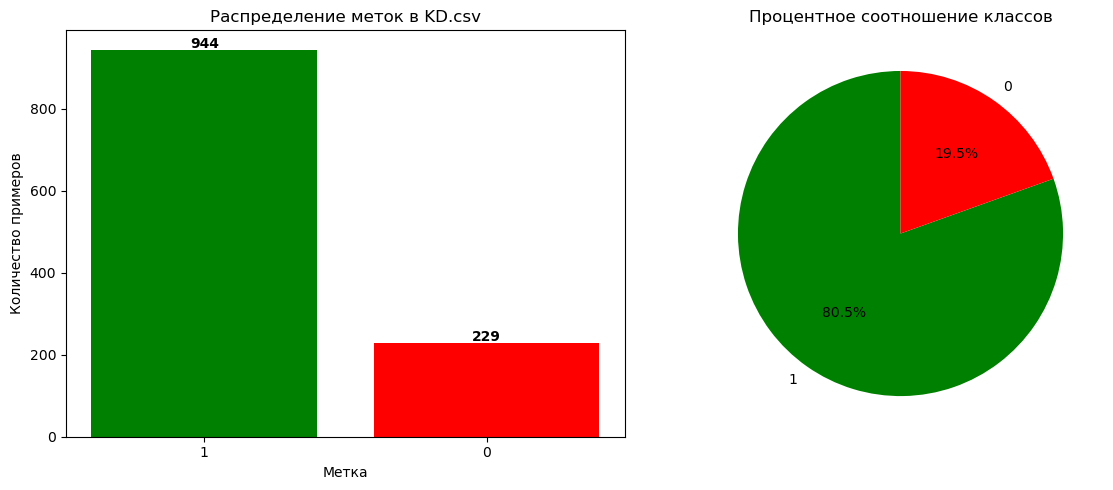


График сохранён в 'kd_labels_distribution.png'


In [5]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df_kd = pd.read_csv('data/KD.csv', index_col=0)

print("="*80)
print("АНАЛИЗ ФАЙЛА KD.csv")
print("="*80)

# 1. Общая информация
print("\n1. ОБЩАЯ ИНФОРМАЦИЯ:")
print(f"   - Всего строк (примеров): {len(df_kd)}")
print(f"   - Всего столбцов (признаков): {len(df_kd.columns)}")
print(f"   - Размер датасета: {df_kd.shape}")

# 2. Анализ колонки 'label'
print("\n2. АНАЛИЗ КОЛОНКИ 'label':")
print(f"   - Тип данных: {df_kd['label'].dtype}")

# Уникальные значения и их количество
unique_labels = df_kd['label'].unique()
print(f"   - Уникальные значения: {unique_labels}")

# Проверка на пропуски
null_count = df_kd['label'].isnull().sum()
print(f"   - Пропуски (NaN): {null_count} ({null_count/len(df_kd)*100:.2f}%)")

# Распределение значений
label_counts = df_kd['label'].value_counts()
print(f"\n   РАСПРЕДЕЛЕНИЕ МЕТОК:")
for label, count in label_counts.items():
    percentage = count / len(df_kd) * 100
    print(f"   - {label}: {count} экземпляров ({percentage:.2f}%)")

# 3. Анализ колонки 'group' (если есть)
if 'group' in df_kd.columns:
    print("\n3. АНАЛИЗ КОЛОНКИ 'group':")
    print(f"   - Тип данных: {df_kd['group'].dtype}")
    unique_groups = df_kd['group'].unique()
    print(f"   - Уникальные значения: {unique_groups[:10]}")  # первые 10
    print(f"   - Всего уникальных групп: {len(unique_groups)}")
    
    group_counts = df_kd['group'].value_counts()
    print(f"\n   ТОП-5 ГРУПП ПО ЧАСТОТЕ:")
    for group, count in group_counts.head(5).items():
        print(f"   - {group}: {count} экземпляров")

# 4. Проверка на дубликаты
print("\n4. ПРОВЕРКА НА ДУБЛИКАТЫ:")
duplicates_by_id = df_kd.index.duplicated().sum()
print(f"   - Дубликаты по индексу (ID): {duplicates_by_id}")

if 'text' in df_kd.columns:
    duplicates_by_text = df_kd['text'].duplicated().sum()
    print(f"   - Дубликаты по тексту: {duplicates_by_text}")

# 5. Распределение по label и group (кросс-таблица)
if 'group' in df_kd.columns:
    print("\n5. КРОСС-ТАБЛИЦА: label vs group:")
    cross_tab = pd.crosstab(df_kd['label'], df_kd['group'], margins=True)
    print(cross_tab)

# 6. Анализ числовых значений в label (если это числа)
print("\n6. СТАТИСТИКА ПО ЧИСЛОВЫМ ЗНАЧЕНИЯМ label:")
if pd.api.types.is_numeric_dtype(df_kd['label']):
    print(f"   - Минимум: {df_kd['label'].min()}")
    print(f"   - Максимум: {df_kd['label'].max()}")
    print(f"   - Среднее: {df_kd['label'].mean():.4f}")
    print(f"   - Медиана: {df_kd['label'].median()}")

# 7. Детальный анализ для строковых меток
if df_kd['label'].dtype == 'object':
    print("\n7. ДЕТАЛЬНЫЙ АНАЛИЗ СТРОКОВЫХ МЕТОК:")
    # Поиск похожих значений (регистронезависимо)
    label_lower = df_kd['label'].str.lower()
    unique_variants = label_lower.unique()
    print(f"   - Варианты написания (lowercase): {unique_variants}")
    
    # Проверка на ключевые слова
    keywords = {
        'депрессия': ['депрессия', 'depression', 'депрессивность'],
        'здоровые': ['здоровые', 'healthy', 'нет депрессии'],
        'высокая': ['высокая', 'high'],
        'низкая': ['низкая', 'low']
    }
    
    for category, words in keywords.items():
        count = 0
        for word in words:
            count += label_lower.str.contains(word, na=False).sum()
        if count > 0:
            print(f"   - Содержат '{category}': {count} экземпляров")

# 8. Примеры записей с разными метками
print("\n8. ПРИМЕРЫ ЗАПИСЕЙ С РАЗНЫМИ МЕТКАМИ:")
for label in unique_labels[:5]:  # первые 5 уникальных меток
    samples = df_kd[df_kd['label'] == label].head(2)
    print(f"\n   Метка: {label}")
    for idx, row in samples.iterrows():
        if 'text' in row:
            text_preview = str(row['text'])[:100] + "..." if len(str(row['text'])) > 100 else str(row['text'])
            print(f"      - ID {idx}: {text_preview}")
        else:
            print(f"      - ID {idx}")

# 9. Проверка на скрытый дисбаланс (если меток несколько)
print("\n9. ИНДЕКС ДИСБАЛАНСА:")
if len(label_counts) > 1:
    max_count = label_counts.max()
    min_count = label_counts.min()
    imbalance_ratio = max_count / min_count
    print(f"   - Соотношение мажоритарный/миноритарный: {imbalance_ratio:.2f}:1")
    
    if imbalance_ratio > 3:
        print(f"   ⚠️  СЕРЬЁЗНЫЙ ДИСБАЛАНС! Миноритарный класс имеет в {imbalance_ratio:.1f} раз меньше примеров")
    elif imbalance_ratio > 1.5:
        print(f"   ⚠️  Умеренный дисбаланс")
    else:
        print(f"   ✅ Хороший баланс классов")

# 10. Сохранение полного отчета
print("\n10. СОХРАНЕНИЕ ОТЧЕТА:")
report = {
    'total_samples': len(df_kd),
    'total_features': len(df_kd.columns),
    'label_column_type': str(df_kd['label'].dtype),
    'unique_labels': unique_labels.tolist(),
    'label_distribution': label_counts.to_dict(),
    'null_count': null_count,
    'imbalance_ratio': imbalance_ratio if len(label_counts) > 1 else None
}

print("   Отчёт сохранён в переменную 'kd_analysis_report'")
print("\n" + "="*80)

# Дополнительно: визуализация распределения
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График 1: Распределение меток
axes[0].bar(range(len(label_counts)), label_counts.values, color=['green', 'red', 'blue'][:len(label_counts)])
axes[0].set_xticks(range(len(label_counts)))
axes[0].set_xticklabels([str(l) for l in label_counts.index])
axes[0].set_title('Распределение меток в KD.csv')
axes[0].set_xlabel('Метка')
axes[0].set_ylabel('Количество примеров')

# Добавляем значения на столбцы
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(i, count + 5, str(count), ha='center', fontweight='bold')

# График 2: Процентное соотношение
if len(label_counts) == 2:
    axes[1].pie(label_counts.values, labels=[str(l) for l in label_counts.index], 
                autopct='%1.1f%%', colors=['green', 'red'], startangle=90)
    axes[1].set_title('Процентное соотношение классов')
else:
    axes[1].barh(range(len(label_counts)), label_counts.values, color='skyblue')
    axes[1].set_yticks(range(len(label_counts)))
    axes[1].set_yticklabels([str(l) for l in label_counts.index])
    axes[1].set_title('Распределение меток')
    axes[1].set_xlabel('Количество')

plt.tight_layout()
plt.savefig('kd_labels_distribution.png', dpi=150)
plt.show()

print("\nГрафик сохранён в 'kd_labels_distribution.png'")

ИСХОДНЫЕ ДАННЫЕ
KA (тревожность): (805, 156), распределение: {1: 432, 0: 373}
KD (депрессия): (1173, 156), распределение: {1: 944, 0: 229}

ПОСЛЕ ОЧИСТКИ
KA: (805, 132)
KD: (1173, 133)

Объединённый датасет: (1978, 133)

РАЗБИВКА ВЫБОРОК
Train: (1285, 131), депрессия: 894, здоровые: 391
Val: (297, 131), депрессия: 207, здоровые: 90
Test: (396, 131), депрессия: 275, здоровые: 121

Пропуски после импутации: 0

МЕТОДЫ БОРЬБЫ С ДИСБАЛАНСОМ

1. SMOTE (Synthetic Minority Over-sampling)
   До: {0: 391, 1: 894}
   После: {0: 894, 1: 894}

2. ADASYN (Adaptive Synthetic Sampling)
   До: {0: 391, 1: 894}
   После: {0: 852, 1: 894}

3. SMOTE + Tomek Links (удаляет пограничные примеры)
   До: {0: 391, 1: 894}
   После: {0: 887, 1: 887}

4. Random Under-sampling (удаляем из класса 1)
   До: {0: 391, 1: 894}
   После: {0: 391, 1: 391}

СРАВНЕНИЕ МЕТОДОВ НА ВАЛИДАЦИИ

Original (imbalanced):
   F1-score: 0.8330, AUC: 0.7328
   Sensitivity (обнаружение депрессии): 0.9275
   Specificity (обнаружение здор

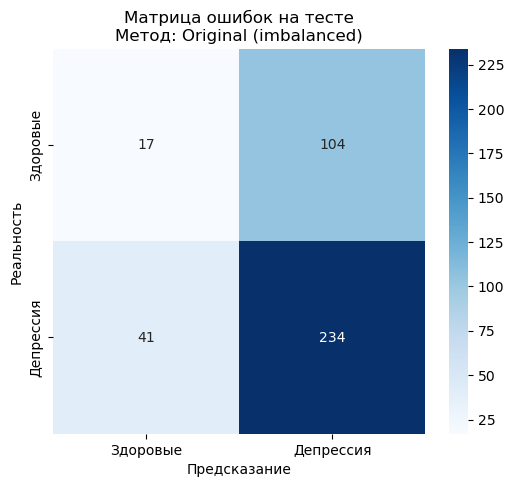


ТОП-20 ВАЖНЕЙШИХ ПРИЗНАКОВ
                    feature  importance
                ew_negative    0.028973
                postag_APRO    0.022287
 tgw_bodily_states_emotions    0.020772
                      nsubj    0.017953
         average_edu_length    0.017732
tgw_cognitive_communication    0.017716
             sentiment_rate    0.015692
              mean_word_len    0.015558
                  postag_PR    0.015439
           pro_1p_sing_rate    0.015149
                      punct    0.014446
              negation_rate    0.013499
              verbs_1p_rate    0.013175
                       case    0.012950
                  inf_group    0.012698
         pro_1p_plural_rate    0.012672
          average_du_length    0.012601
          unique_words_rate    0.012214
                        det    0.012096
                   postag_V    0.011992


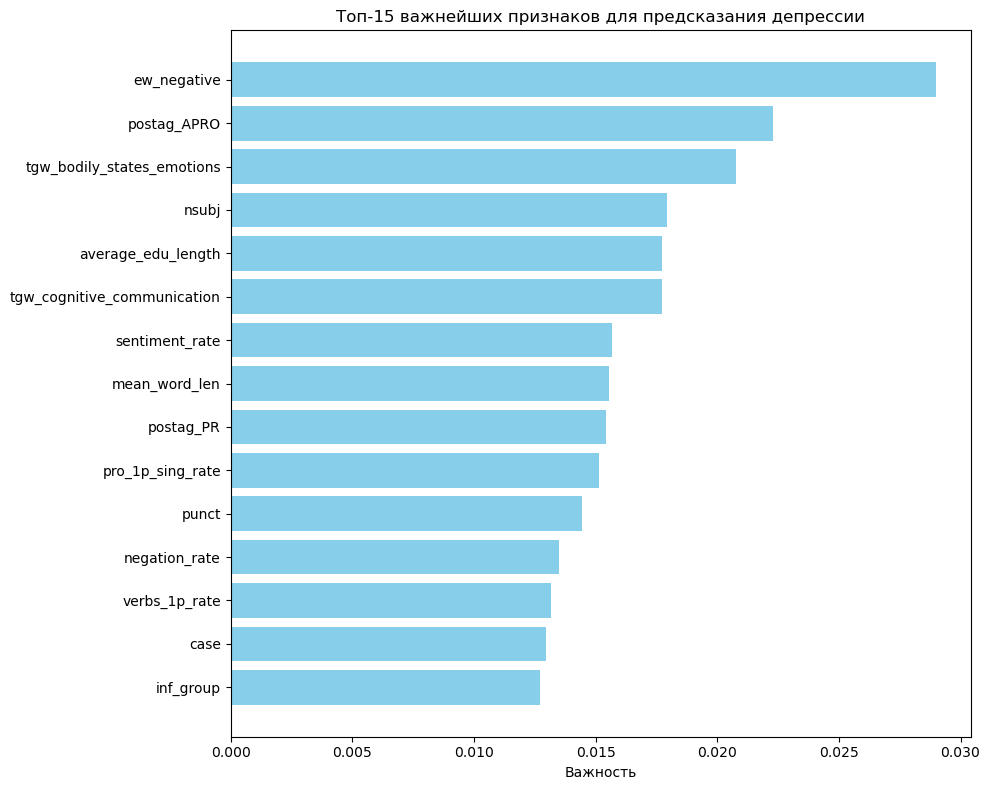


СОХРАНЕНИЕ ДАННЫХ ДЛЯ НЕЙРОСЕТИ
✅ Файлы сохранены:
   - X_train_balanced.csv, y_train_balanced.csv (сбалансированные train)
   - X_val_prepared.csv, y_val.csv (валидация)
   - X_test_prepared.csv, y_test.csv (тест)

РЕКОМЕНДАЦИИ

💡 Для вашей задачи рекомендуется:

1. ИСПОЛЬЗОВАТЬ МЕТОД: Original (imbalanced) (показал лучший F1-score на валидации)

2. ДЛЯ НЕЙРОСЕТИ:
   - Использовать class_weight или сбалансированные данные
   - Применить Focal Loss (фокусируется на трудных примерах)
   - Добавить Dropout для регуляризации (0.3-0.5)

3. КЛЮЧЕВЫЕ ПРИЗНАКИ (топ-5):
   - ew_negative
   - postag_APRO
   - tgw_bodily_states_emotions
   - nsubj
   - average_edu_length

4. ПОРОГ КЛАССИФИКАЦИИ:
   - Для клинической задачи (не пропустить депрессию) → снизить порог до 0.3-0.4
   - Для баланса ошибок → оставить 0.5


✅ Дополнительные файлы сохранены:
   - methods_comparison.csv (сравнение методов)
   - feature_importance_full.csv (все признаки с важностью)


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ===============================
# 1. ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ
# ===============================
df_ka = pd.read_csv('data/KA.csv', index_col=0)
df_kd = pd.read_csv('data/KD.csv', index_col=0)

print("="*80)
print("ИСХОДНЫЕ ДАННЫЕ")
print("="*80)
print(f"KA (тревожность): {df_ka.shape}, распределение: {df_ka['label'].value_counts().to_dict()}")
print(f"KD (депрессия): {df_kd.shape}, распределение: {df_kd['label'].value_counts().to_dict()}")

# ===============================
# 2. ОЧИСТКА ДАННЫХ
# ===============================
# Удаляем явно шумные признаки
noise_features = [
    'ID', 'group', 'text', 'flat:foreign:', 'goeswith', 'list', 'orphan',
    'punctuation_per_word', 'uppercase_rate', 'be_calm_excitement', 
    'be_happyness', 'be_wonder', 'tgw_security_structures', 'tgw_economics',
    'tgw_catastrophes', 'tgw_hcs', 'tgw_positive_assessment', 
    'tgw_positive_social', 'tgw_positive_emotions', 'ew_positive',
    'number_of_trees', 'first_tree_edus_number'
]

for df in [df_ka, df_kd]:
    for feat in noise_features:
        if feat in df.columns:
            df.drop(columns=[feat], inplace=True)
    
    # Удаляем константные колонки
    df.drop(columns=[col for col in df.columns if df[col].nunique() <= 1], inplace=True)

print("\n" + "="*80)
print("ПОСЛЕ ОЧИСТКИ")
print("="*80)
print(f"KA: {df_ka.shape}")
print(f"KD: {df_kd.shape}")

# ===============================
# 3. ОБЪЕДИНЕНИЕ ДАТАСЕТОВ
# ===============================
df_ka['task'] = 'anxiety'
df_kd['task'] = 'depression'

common_cols = list(set(df_ka.columns) & set(df_kd.columns))
df_ka = df_ka[common_cols]
df_kd = df_kd[common_cols]

df_combined = pd.concat([df_ka, df_kd], axis=0, ignore_index=True)
print(f"\nОбъединённый датасет: {df_combined.shape}")

# ===============================
# 4. РАЗДЕЛЕНИЕ НА ВЫБОРКИ (стратифицированное)
# ===============================
X = df_combined.drop(columns=['label', 'task'])
y = df_combined['label']
task = df_combined['task']

# Сначала отделяем тест (20%)
X_temp, X_test, y_temp, y_test, task_temp, task_test = train_test_split(
    X, y, task, test_size=0.2, stratify=y, random_state=42
)

# Потом валидацию (15% от исходного, т.е. ~19% от temp)
X_train, X_val, y_train, y_val, task_train, task_val = train_test_split(
    X_temp, y_temp, task_temp, test_size=0.1875, stratify=y_temp, random_state=42
)

print("\n" + "="*80)
print("РАЗБИВКА ВЫБОРОК")
print("="*80)
print(f"Train: {X_train.shape}, депрессия: {(y_train==1).sum()}, здоровые: {(y_train==0).sum()}")
print(f"Val: {X_val.shape}, депрессия: {(y_val==1).sum()}, здоровые: {(y_val==0).sum()}")
print(f"Test: {X_test.shape}, депрессия: {(y_test==1).sum()}, здоровые: {(y_test==0).sum()}")

# ===============================
# 5. ОБРАБОТКА ПРОПУСКОВ
# ===============================
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_val_imp = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

print(f"\nПропуски после импутации: {X_train_imp.isnull().sum().sum()}")

# ===============================
# 6. НОРМАЛИЗАЦИЯ
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

# ===============================
# 7. РЕШЕНИЕ ПРОБЛЕМЫ ДИСБАЛАНСА (4 способа)
# ===============================

print("\n" + "="*80)
print("МЕТОДЫ БОРЬБЫ С ДИСБАЛАНСОМ")
print("="*80)

# Сохраняем оригинальные данные для сравнения
X_train_original = X_train_scaled.copy()
y_train_original = y_train.copy()

# Способ 1: SMOTE (синтетическая генерация)
print("\n1. SMOTE (Synthetic Minority Over-sampling)")
smote = SMOTE(random_state=42, k_neighbors=min(3, min(np.bincount(y_train))-1))
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"   До: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"   После: {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")

# Способ 2: ADASYN (адаптивная генерация)
print("\n2. ADASYN (Adaptive Synthetic Sampling)")
adasyn = ADASYN(random_state=42, n_neighbors=min(3, min(np.bincount(y_train))-1))
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print(f"   До: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"   После: {dict(zip(*np.unique(y_train_adasyn, return_counts=True)))}")

# Способ 3: SMOTE + Tomek (удаление шума)
print("\n3. SMOTE + Tomek Links (удаляет пограничные примеры)")
smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train)
print(f"   До: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"   После: {dict(zip(*np.unique(y_train_tomek, return_counts=True)))}")

# Способ 4: Андерсэмплинг (удаление из мажоритарного класса)
print("\n4. Random Under-sampling (удаляем из класса 1)")
under = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under.fit_resample(X_train_scaled, y_train)
print(f"   До: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"   После: {dict(zip(*np.unique(y_train_under, return_counts=True)))}")

# ===============================
# 8. СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ
# ===============================

print("\n" + "="*80)
print("СРАВНЕНИЕ МЕТОДОВ НА ВАЛИДАЦИИ")
print("="*80)

# Используем Random Forest для сравнения (устойчив к дисбалансу)
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Словарь с методами
methods = {
    'Original (imbalanced)': (X_train_original, y_train_original),
    'SMOTE': (X_train_smote, y_train_smote),
    'ADASYN': (X_train_adasyn, y_train_adasyn),
    'SMOTE+Tomek': (X_train_tomek, y_train_tomek),
    'Under-sampling': (X_train_under, y_train_under),
}

results = []

for method_name, (X_tr, y_tr) in methods.items():
    # Обучаем модель
    rf_base.fit(X_tr, y_tr)
    
    # Предсказания на валидации
    y_pred = rf_base.predict(X_val_scaled)
    y_pred_proba = rf_base.predict_proba(X_val_scaled)[:, 1]
    
    # Метрики
    f1 = f1_score(y_val, y_pred, average='binary')
    auc = roc_auc_score(y_val, y_pred_proba)
    
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    
    # Специфичность и чувствительность
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    results.append({
        'Method': method_name,
        'Train_size': len(X_tr),
        'F1-score': f1,
        'AUC-ROC': auc,
        'Sensitivity (recall)': sensitivity,
        'Specificity': specificity,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
    })
    
    print(f"\n{method_name}:")
    print(f"   F1-score: {f1:.4f}, AUC: {auc:.4f}")
    print(f"   Sensitivity (обнаружение депрессии): {sensitivity:.4f}")
    print(f"   Specificity (обнаружение здоровых): {specificity:.4f}")

# Выбираем лучший метод по F1-score
results_df = pd.DataFrame(results)
best_method = results_df.loc[results_df['F1-score'].idxmax(), 'Method']
print(f"\n🏆 ЛУЧШИЙ МЕТОД: {best_method}")

# ===============================
# 9. ОБУЧАЕМ ФИНАЛЬНУЮ МОДЕЛЬ С ЛУЧШИМ МЕТОДОМ
# ===============================

print("\n" + "="*80)
print("ФИНАЛЬНАЯ МОДЕЛЬ С ЛУЧШИМ МЕТОДОМ")
print("="*80)

# Получаем данные с лучшим методом
X_train_final, y_train_final = methods[best_method]

# Обучаем финальную модель
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train_final, y_train_final)

# Оценка на ТЕСТОВОЙ выборке
y_test_pred = final_model.predict(X_test_scaled)
y_test_proba = final_model.predict_proba(X_test_scaled)[:, 1]

print("\nРЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ:")
print(classification_report(y_test, y_test_pred, target_names=['Здоровые', 'Депрессия']))

# Матрица ошибок
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Здоровые', 'Депрессия'],
            yticklabels=['Здоровые', 'Депрессия'])
plt.title(f'Матрица ошибок на тесте\nМетод: {best_method}')
plt.ylabel('Реальность')
plt.xlabel('Предсказание')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ===============================
# 10. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
# ===============================

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*80)
print("ТОП-20 ВАЖНЕЙШИХ ПРИЗНАКОВ")
print("="*80)
print(feature_importance.head(20).to_string(index=False))

# Визуализация важности
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'], color='skyblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Важность')
plt.title('Топ-15 важнейших признаков для предсказания депрессии')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# ===============================
# 11. СОХРАНЕНИЕ ДАННЫХ ДЛЯ НЕЙРОСЕТИ
# ===============================

print("\n" + "="*80)
print("СОХРАНЕНИЕ ДАННЫХ ДЛЯ НЕЙРОСЕТИ")
print("="*80)

# Сохраняем предобработанные данные с лучшим методом
pd.DataFrame(X_train_final).to_csv('X_train_balanced.csv', index=False)
pd.DataFrame(y_train_final).to_csv('y_train_balanced.csv', index=False)
pd.DataFrame(X_val_scaled).to_csv('X_val_prepared.csv', index=False)
pd.DataFrame(y_val).to_csv('y_val.csv', index=False)
pd.DataFrame(X_test_scaled).to_csv('X_test_prepared.csv', index=False)
pd.DataFrame(y_test).to_csv('y_test.csv', index=False)

print("✅ Файлы сохранены:")
print("   - X_train_balanced.csv, y_train_balanced.csv (сбалансированные train)")
print("   - X_val_prepared.csv, y_val.csv (валидация)")
print("   - X_test_prepared.csv, y_test.csv (тест)")

# ===============================
# 12. ВЫВОД РЕКОМЕНДАЦИЙ
# ===============================

print("\n" + "="*80)
print("РЕКОМЕНДАЦИИ")
print("="*80)

print("""
💡 Для вашей задачи рекомендуется:

1. ИСПОЛЬЗОВАТЬ МЕТОД: {} (показал лучший F1-score на валидации)

2. ДЛЯ НЕЙРОСЕТИ:
   - Использовать class_weight или сбалансированные данные
   - Применить Focal Loss (фокусируется на трудных примерах)
   - Добавить Dropout для регуляризации (0.3-0.5)

3. КЛЮЧЕВЫЕ ПРИЗНАКИ (топ-5):
   - {}
   - {}
   - {}
   - {}
   - {}

4. ПОРОГ КЛАССИФИКАЦИИ:
   - Для клинической задачи (не пропустить депрессию) → снизить порог до 0.3-0.4
   - Для баланса ошибок → оставить 0.5
""".format(
    best_method,
    top_features.iloc[0]['feature'],
    top_features.iloc[1]['feature'] if len(top_features) > 1 else '-',
    top_features.iloc[2]['feature'] if len(top_features) > 2 else '-',
    top_features.iloc[3]['feature'] if len(top_features) > 3 else '-',
    top_features.iloc[4]['feature'] if len(top_features) > 4 else '-'
))

# Сохраняем результаты сравнения
results_df.to_csv('methods_comparison.csv', index=False)
feature_importance.to_csv('feature_importance_full.csv', index=False)
print("\n✅ Дополнительные файлы сохранены:")
print("   - methods_comparison.csv (сравнение методов)")
print("   - feature_importance_full.csv (все признаки с важностью)")

In [8]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split

# ===============================
# 1. ЗАГРУЗКА ДАННЫХ
# ===============================
df_ka = pd.read_csv('data/KA.csv', index_col=0)
df_kd = pd.read_csv('data/KD.csv', index_col=0)

print("="*80)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ LLM (БИНАРНАЯ КЛАССИФИКАЦИЯ)")
print("="*80)

# ===============================
# 2. ПОДГОТОВКА ДАТАСЕТА ПО ТРЕВОЖНОСТИ
# ===============================

print("\n📊 ДАТАСЕТ ТРЕВОЖНОСТИ (KA.csv)")

# Проверяем метки в KA
print(f"   Оригинальные метки: {df_ka['label'].unique()}")
print(f"   Распределение: {df_ka['label'].value_counts().to_dict()}")

# Тревожность уже бинарная (0/1), просто переименовываем
anxiety_data = pd.DataFrame({
    'text': df_ka['text'],
    'label': df_ka['label'],
    'label_text': df_ka['label'].map({0: 'нет тревожности', 1: 'тревожность'})
})

# Очистка текстов
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s\.\,\!\?\-\;\:\"\'\«\»]', ' ', text)
    return text.strip()

anxiety_data['text_cleaned'] = anxiety_data['text'].apply(clean_text)

print(f"\n   ПОСЛЕ ПРИВЕДЕНИЯ:")
print(f"   Тревожность (1): {(anxiety_data['label']==1).sum()} ({(anxiety_data['label']==1).mean()*100:.1f}%)")
print(f"   Нет тревожности (0): {(anxiety_data['label']==0).sum()} ({(anxiety_data['label']==0).mean()*100:.1f}%)")

# Разбивка на train/val/test
X_anxiety = anxiety_data['text_cleaned']
y_anxiety = anxiety_data['label']

X_anxiety_temp, X_anxiety_test, y_anxiety_temp, y_anxiety_test = train_test_split(
    X_anxiety, y_anxiety, test_size=0.2, stratify=y_anxiety, random_state=42
)

X_anxiety_train, X_anxiety_val, y_anxiety_train, y_anxiety_val = train_test_split(
    X_anxiety_temp, y_anxiety_temp, test_size=0.125, stratify=y_anxiety_temp, random_state=42
)

print(f"\n   РАЗБИВКА:")
print(f"   Train: {len(X_anxiety_train)} (тревожность: {(y_anxiety_train==1).sum()}, нет: {(y_anxiety_train==0).sum()})")
print(f"   Val: {len(X_anxiety_val)} (тревожность: {(y_anxiety_val==1).sum()}, нет: {(y_anxiety_val==0).sum()})")
print(f"   Test: {len(X_anxiety_test)} (тревожность: {(y_anxiety_test==1).sum()}, нет: {(y_anxiety_test==0).sum()})")

# ===============================
# 3. ПОДГОТОВКА ДАТАСЕТА ПО ДЕПРЕССИИ (ПРАВИЛЬНАЯ БИНАРИЗАЦИЯ)
# ===============================

print("\n📊 ДАТАСЕТ ДЕПРЕССИИ (KD.csv)")

# Смотрим оригинальные метки и group
print(f"   Оригинальные метки (label): {df_kd['label'].unique()}")
print(f"   Распределение original label: {df_kd['label'].value_counts().to_dict()}")
print(f"\n   Детализация по group:")
for group, count in df_kd['group'].value_counts().items():
    print(f"   - {group}: {count}")

# ПРАВИЛЬНОЕ ПРЕОБРАЗОВАНИЕ:
# 0 = нет депрессии (здоровые + нет депрессивности + низкая депрессивность)
# 1 = депрессия (депрессия + высокая депрессивность)

# Создаем маппинг на основе колонки 'group'
def map_depression_binary(row):
    group = row['group']
    if group in ['здоровые', 'нет депрессивности', 'низкая депрессивность']:
        return 0  # нет депрессии
    elif group in ['депрессия', 'высокая депрессивность']:
        return 1  # депрессия
    else:
        return np.nan

df_kd['label_binary'] = df_kd.apply(map_depression_binary, axis=1)

# Проверяем результат
print(f"\n   ПОСЛЕ ПРИВЕДЕНИЯ К БИНАРНОМУ ВИДУ:")
print(f"   Депрессия (1): {(df_kd['label_binary']==1).sum()} ({(df_kd['label_binary']==1).mean()*100:.1f}%)")
print(f"   Нет депрессии (0): {(df_kd['label_binary']==0).sum()} ({(df_kd['label_binary']==0).mean()*100:.1f}%)")

# Проверяем правильность маппинга
print(f"\n   ПРОВЕРКА МАППИНГА:")
for group in df_kd['group'].unique():
    binary_val = df_kd[df_kd['group'] == group]['label_binary'].iloc[0]
    print(f"   {group} → {binary_val} ({'депрессия' if binary_val==1 else 'нет депрессии'})")

# Удаляем строки с ошибками (если есть)
df_kd = df_kd.dropna(subset=['label_binary'])
df_kd['label_binary'] = df_kd['label_binary'].astype(int)

# Создаем датасет для депрессии
depression_data = pd.DataFrame({
    'text': df_kd['text'],
    'label': df_kd['label_binary'],
    'label_text': df_kd['label_binary'].map({0: 'нет депрессии', 1: 'депрессия'}),
    'group': df_kd['group']  # сохраняем исходную группу для анализа
})

# Очистка текстов
depression_data['text_cleaned'] = depression_data['text'].apply(clean_text)

# Разбивка на train/val/test
X_depression = depression_data['text_cleaned']
y_depression = depression_data['label']

X_depression_temp, X_depression_test, y_depression_temp, y_depression_test = train_test_split(
    X_depression, y_depression, test_size=0.2, stratify=y_depression, random_state=42
)

X_depression_train, X_depression_val, y_depression_train, y_depression_val = train_test_split(
    X_depression_temp, y_depression_temp, test_size=0.125, stratify=y_depression_temp, random_state=42
)

print(f"\n   РАЗБИВКА:")
print(f"   Train: {len(X_depression_train)} (депрессия: {(y_depression_train==1).sum()}, нет: {(y_depression_train==0).sum()})")
print(f"   Val: {len(X_depression_val)} (депрессия: {(y_depression_val==1).sum()}, нет: {(y_depression_val==0).sum()})")
print(f"   Test: {len(X_depression_test)} (депрессия: {(y_depression_test==1).sum()}, нет: {(y_depression_test==0).sum()})")

# ===============================
# 4. СОЗДАНИЕ ПРОМПТОВ ДЛЯ LLM
# ===============================

print("\n" + "="*80)
print("СОЗДАНИЕ ПРОМПТОВ ДЛЯ LLM")
print("="*80)

def create_anxiety_prompt(text):
    """Промпт для определения тревожности (бинарный)"""
    return f"""Ты клинический психолог. Определи, есть ли у пользователя признаки тревожности на основе его текста.

Текст пользователя:
\"\"\"
{text}
\"\"\"

Выбери один из двух вариантов:
- ТРЕВОЖНОСТЬ (есть明显ные признаки тревоги, беспокойства, страха)
- НЕТ ТРЕВОЖНОСТИ (спокойное, уравновешенное состояние)

Ответь строго в формате:
Диагноз: [ТРЕВОЖНОСТЬ/НЕТ ТРЕВОЖНОСТИ]
Обоснование: [1-2 предложения с ключевыми признаками]"""

def create_depression_prompt(text):
    """Промпт для определения депрессии (бинарный)"""
    return f"""Ты клинический психолог. Определи, есть ли у пользователя признаки депрессии на основе его текста.

Текст пользователя:
\"\"\"
{text}
\"\"\"

Выбери один из двух вариантов:
- ДЕПРЕССИЯ (есть признаки: подавленное настроение, ангедония, усталость, чувство безнадежности, снижение энергии)
- НЕТ ДЕПРЕССИИ (нормальное настроение, интерес к жизни, активность)

Ответь строго в формате:
Диагноз: [ДЕПРЕССИЯ/НЕТ ДЕПРЕССИИ]
Обоснование: [1-2 предложения с ключевыми признаками]"""

# Создаем промпты для train
anxiety_train_df = pd.DataFrame({
    'text': X_anxiety_train.values,
    'label': y_anxiety_train.values,
    'label_text': y_anxiety_train.map({0: 'нет тревожности', 1: 'тревожность'}).values,
    'prompt': [create_anxiety_prompt(t) for t in X_anxiety_train.values]
})

depression_train_df = pd.DataFrame({
    'text': X_depression_train.values,
    'label': y_depression_train.values,
    'label_text': y_depression_train.map({0: 'нет депрессии', 1: 'депрессия'}).values,
    'group': depression_data.iloc[X_depression_train.index]['group'].values,
    'prompt': [create_depression_prompt(t) for t in X_depression_train.values]
})

# Валидация и тест без промптов (только текст и метка)
anxiety_val_df = pd.DataFrame({
    'text': X_anxiety_val.values,
    'label': y_anxiety_val.values,
    'label_text': y_anxiety_val.map({0: 'нет тревожности', 1: 'тревожность'}).values
})

anxiety_test_df = pd.DataFrame({
    'text': X_anxiety_test.values,
    'label': y_anxiety_test.values,
    'label_text': y_anxiety_test.map({0: 'нет тревожности', 1: 'тревожность'}).values
})

depression_val_df = pd.DataFrame({
    'text': X_depression_val.values,
    'label': y_depression_val.values,
    'label_text': y_depression_val.map({0: 'нет депрессии', 1: 'депрессия'}).values,
    'group': depression_data.iloc[X_depression_val.index]['group'].values
})

depression_test_df = pd.DataFrame({
    'text': X_depression_test.values,
    'label': y_depression_test.values,
    'label_text': y_depression_test.map({0: 'нет депрессии', 1: 'депрессия'}).values,
    'group': depression_data.iloc[X_depression_test.index]['group'].values
})

# ===============================
# 5. СОХРАНЕНИЕ ФАЙЛОВ
# ===============================

print("\n" + "="*80)
print("СОХРАНЕНИЕ ДАННЫХ")
print("="*80)

anxiety_train_df.to_csv('anxiety_train.csv', index=False)
anxiety_val_df.to_csv('anxiety_val.csv', index=False)
anxiety_test_df.to_csv('anxiety_test.csv', index=False)

depression_train_df.to_csv('depression_train.csv', index=False)
depression_val_df.to_csv('depression_val.csv', index=False)
depression_test_df.to_csv('depression_test.csv', index=False)

print("\n✅ ФАЙЛЫ СОХРАНЕНЫ:")
print("\n📁 Тревожность:")
print(f"   - anxiety_train.csv ({len(anxiety_train_df)} примеров, с промптами)")
print(f"   - anxiety_val.csv ({len(anxiety_val_df)} примеров)")
print(f"   - anxiety_test.csv ({len(anxiety_test_df)} примеров)")

print("\n📁 Депрессия:")
print(f"   - depression_train.csv ({len(depression_train_df)} примеров, с промптами)")
print(f"   - depression_val.csv ({len(depression_val_df)} примеров)")
print(f"   - depression_test.csv ({len(depression_test_df)} примеров)")

# ===============================
# 6. ФИНАЛЬНАЯ СТАТИСТИКА
# ===============================

print("\n" + "="*80)
print("ИТОГОВАЯ СТАТИСТИКА")
print("="*80)

print("\n📊 ТРЕВОЖНОСТЬ (бинарная):")
print(f"   Всего: {len(anxiety_data)}")
print(f"   Тревожность: {(anxiety_data['label']==1).sum()} ({(anxiety_data['label']==1).mean()*100:.1f}%)")
print(f"   Нет тревожности: {(anxiety_data['label']==0).sum()} ({(anxiety_data['label']==0).mean()*100:.1f}%)")
print(f"   Средняя длина текста: {anxiety_data['text_cleaned'].str.len().mean():.0f} символов")

print("\n📊 ДЕПРЕССИЯ (бинарная, правильная группировка):")
print(f"   Всего: {len(depression_data)}")
print(f"   Депрессия: {(depression_data['label']==1).sum()} ({(depression_data['label']==1).mean()*100:.1f}%)")
print(f"   Нет депрессии: {(depression_data['label']==0).sum()} ({(depression_data['label']==0).mean()*100:.1f}%)")
print(f"   Средняя длина текста: {depression_data['text_cleaned'].str.len().mean():.0f} символов")

print("\n📊 ДЕТАЛИЗАЦИЯ ДЕПРЕССИИ (исходные группы):")
for group in ['здоровые', 'нет депрессивности', 'низкая депрессивность', 'депрессия', 'высокая депрессивность']:
    count = len(depression_data[depression_data['group'] == group])
    if count > 0:
        label = depression_data[depression_data['group'] == group]['label'].iloc[0]
        status = "ДЕПРЕССИЯ" if label == 1 else "НЕТ ДЕПРЕССИИ"
        print(f"   {group}: {count} примеров → {status}")

# ===============================
# 7. ПРИМЕРЫ ДАННЫХ
# ===============================

print("\n" + "="*80)
print("ПРИМЕРЫ ДАННЫХ ДЛЯ LLM")
print("="*80)

print("\n🔴 ПРИМЕР 1: Тревожность")
anxiety_sample = anxiety_data[anxiety_data['label']==1].iloc[0]
print(f"Текст: {anxiety_sample['text_cleaned'][:200]}...")
print(f"Метка: {anxiety_sample['label_text']}")
print(f"\nПромпт для LLM:")
print(create_anxiety_prompt(anxiety_sample['text_cleaned'][:200] + "...")[:500] + "...")

print("\n🔴 ПРИМЕР 2: Депрессия")
depression_sample = depression_data[depression_data['label']==1].iloc[0]
print(f"Текст: {depression_sample['text_cleaned'][:200]}...")
print(f"Метка: {depression_sample['label_text']}")
print(f"Исходная группа: {depression_sample['group']}")
print(f"\nПромпт для LLM:")
print(create_depression_prompt(depression_sample['text_cleaned'][:200] + "...")[:500] + "...")

print("\n" + "="*80)
print("ГОТОВО! ДАННЫЕ ПОДГОТОВЛЕНЫ ДЛЯ LLM")
print("="*80)

ПОДГОТОВКА ДАННЫХ ДЛЯ LLM (БИНАРНАЯ КЛАССИФИКАЦИЯ)

📊 ДАТАСЕТ ТРЕВОЖНОСТИ (KA.csv)
   Оригинальные метки: [0 1]
   Распределение: {1: 432, 0: 373}

   ПОСЛЕ ПРИВЕДЕНИЯ:
   Тревожность (1): 432 (53.7%)
   Нет тревожности (0): 373 (46.3%)

   РАЗБИВКА:
   Train: 563 (тревожность: 302, нет: 261)
   Val: 81 (тревожность: 44, нет: 37)
   Test: 161 (тревожность: 86, нет: 75)

📊 ДАТАСЕТ ДЕПРЕССИИ (KD.csv)
   Оригинальные метки (label): [0 1]
   Распределение original label: {1: 944, 0: 229}

   Детализация по group:
   - здоровые: 447
   - нет депрессивности: 362
   - низкая депрессивность: 135
   - высокая депрессивность: 119
   - депрессия: 110

   ПОСЛЕ ПРИВЕДЕНИЯ К БИНАРНОМУ ВИДУ:
   Депрессия (1): 229 (19.5%)
   Нет депрессии (0): 944 (80.5%)

   ПРОВЕРКА МАППИНГА:
   депрессия → 1 (депрессия)
   здоровые → 0 (нет депрессии)
   низкая депрессивность → 0 (нет депрессии)
   высокая депрессивность → 1 (депрессия)
   нет депрессивности → 0 (нет депрессии)

   РАЗБИВКА:
   Train: 820 (депресс

In [11]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split

# ===============================
# 1. ЗАГРУЗКА ДАННЫХ
# ===============================
df_ka = pd.read_csv('data/KA.csv', index_col=0)
df_kd = pd.read_csv('data/KD.csv', index_col=0)

print("="*80)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ LLM")
print("="*80)

# Очистка текстов
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s\.\,\!\?\-\;\:\"\'\«\»]', ' ', text)
    return text.strip()

# ===============================
# 2. ТРЕВОЖНОСТЬ
# ===============================
print("\n📊 ТРЕВОЖНОСТЬ")

def create_anxiety_prompt(text):
    return f"""Ты клинический психолог. Определи, есть ли у пользователя признаки тревожности.

Текст: {text}

Ответь строго в формате:
Диагноз: [ТРЕВОЖНОСТЬ/НЕТ ТРЕВОЖНОСТИ]
Обоснование: [1 предложение]"""

# Создаем датасет
anxiety_data = pd.DataFrame({
    'text': df_ka['text'].apply(clean_text),
    'label_text': df_ka['label'].map({0: 'НЕТ ТРЕВОЖНОСТИ', 1: 'ТРЕВОЖНОСТЬ'})
})

# Удаляем пустые и слишком короткие тексты (менее 20 символов)
anxiety_data = anxiety_data[anxiety_data['text'].str.len() >= 20]
anxiety_data = anxiety_data.reset_index(drop=True)

print(f"   Всего: {len(anxiety_data)}")
print(f"   ТРЕВОЖНОСТЬ: {(anxiety_data['label_text']=='ТРЕВОЖНОСТЬ').sum()}")
print(f"   НЕТ ТРЕВОЖНОСТИ: {(anxiety_data['label_text']=='НЕТ ТРЕВОЖНОСТИ').sum()}")

# Разбивка (стратифицированная)
X = anxiety_data['text']
y = anxiety_data['label_text']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

# Создаем промпты ДО сортировки
train_df = pd.DataFrame({
    'text': X_train,
    'label': y_train
})
# Добавляем длину текста
train_df['length'] = train_df['text'].str.len()
# Сортируем ПОСЛЕ создания всех данных (от длинных к коротким)
train_df = train_df.sort_values('length', ascending=False).drop(columns=['length'])

val_df = pd.DataFrame({
    'text': X_val,
    'label': y_val
})
val_df['length'] = val_df['text'].str.len()
val_df = val_df.sort_values('length', ascending=False).drop(columns=['length'])

test_df = pd.DataFrame({
    'text': X_test,
    'label': y_test
})
test_df['length'] = test_df['text'].str.len()
test_df = test_df.sort_values('length', ascending=False).drop(columns=['length'])

# Создаем промпты
anxiety_train = pd.DataFrame({
    'prompt': [create_anxiety_prompt(text) for text in train_df['text']],
    'label': train_df['label'].values
})

anxiety_val = pd.DataFrame({
    'prompt': [create_anxiety_prompt(text) for text in val_df['text']],
    'label': val_df['label'].values
})

anxiety_test = pd.DataFrame({
    'prompt': [create_anxiety_prompt(text) for text in test_df['text']],
    'label': test_df['label'].values
})

# ===============================
# 3. ДЕПРЕССИЯ
# ===============================
print("\n📊 ДЕПРЕССИЯ")

def create_depression_prompt(text):
    return f"""Ты клинический психолог. Определи, есть ли у пользователя признаки депрессии.

Текст: {text}

Ответь строго в формате:
Диагноз: [ДЕПРЕССИЯ/НЕТ ДЕПРЕССИИ]
Обоснование: [1 предложение]"""

# Функция бинаризации депрессии
def map_depression(row):
    group = row['group']
    if group in ['здоровые', 'нет депрессивности', 'низкая депрессивность']:
        return 'НЕТ ДЕПРЕССИИ'
    elif group in ['депрессия', 'высокая депрессивность']:
        return 'ДЕПРЕССИЯ'
    else:
        return None

df_kd['label_text'] = df_kd.apply(map_depression, axis=1)
df_kd = df_kd.dropna(subset=['label_text'])

# Создаем датасет
depression_data = pd.DataFrame({
    'text': df_kd['text'].apply(clean_text),
    'label_text': df_kd['label_text'],
    'group': df_kd['group']
})

# Удаляем пустые и слишком короткие тексты
depression_data = depression_data[depression_data['text'].str.len() >= 20]
depression_data = depression_data.reset_index(drop=True)

print(f"   Всего: {len(depression_data)}")
print(f"   ДЕПРЕССИЯ: {(depression_data['label_text']=='ДЕПРЕССИЯ').sum()}")
print(f"   НЕТ ДЕПРЕССИИ: {(depression_data['label_text']=='НЕТ ДЕПРЕССИИ').sum()}")

print("\n   Детализация по группам:")
for group in ['здоровые', 'нет депрессивности', 'низкая депрессивность', 'депрессия', 'высокая депрессивность']:
    count = len(depression_data[depression_data['group'] == group])
    if count > 0:
        label = depression_data[depression_data['group'] == group]['label_text'].iloc[0]
        print(f"   {group}: {count} → {label}")

# Разбивка
X = depression_data['text']
y = depression_data['label_text']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

# Создаем промпты ДО сортировки
train_dep_df = pd.DataFrame({
    'text': X_train,
    'label': y_train
})
train_dep_df['length'] = train_dep_df['text'].str.len()
train_dep_df = train_dep_df.sort_values('length', ascending=False).drop(columns=['length'])

val_dep_df = pd.DataFrame({
    'text': X_val,
    'label': y_val
})
val_dep_df['length'] = val_dep_df['text'].str.len()
val_dep_df = val_dep_df.sort_values('length', ascending=False).drop(columns=['length'])

test_dep_df = pd.DataFrame({
    'text': X_test,
    'label': y_test
})
test_dep_df['length'] = test_dep_df['text'].str.len()
test_dep_df = test_dep_df.sort_values('length', ascending=False).drop(columns=['length'])

# Создаем промпты
depression_train = pd.DataFrame({
    'prompt': [create_depression_prompt(text) for text in train_dep_df['text']],
    'label': train_dep_df['label'].values
})

depression_val = pd.DataFrame({
    'prompt': [create_depression_prompt(text) for text in val_dep_df['text']],
    'label': val_dep_df['label'].values
})

depression_test = pd.DataFrame({
    'prompt': [create_depression_prompt(text) for text in test_dep_df['text']],
    'label': test_dep_df['label'].values
})

# ===============================
# 4. СОХРАНЕНИЕ
# ===============================
print("\n" + "="*80)
print("СОХРАНЕНИЕ")
print("="*80)

anxiety_train.to_csv('anxiety_train.csv', index=False)
anxiety_val.to_csv('anxiety_val.csv', index=False)
anxiety_test.to_csv('anxiety_test.csv', index=False)

depression_train.to_csv('depression_train.csv', index=False)
depression_val.to_csv('depression_val.csv', index=False)
depression_test.to_csv('depression_test.csv', index=False)

# ===============================
# 5. ПРОВЕРКА СОРТИРОВКИ
# ===============================
print("\n" + "="*80)
print("ПРОВЕРКА СОРТИРОВКИ")
print("="*80)

print("\n📊 Тревожность train — первые 5 строк (должны быть самыми длинными):")
for i in range(min(5, len(anxiety_train))):
    text_preview = anxiety_train.iloc[i]['prompt'].split('Текст: ')[1].split('Ответь')[0][:80]
    print(f"{i+1}. Длина: {len(anxiety_train.iloc[i]['prompt'])}, текст: {text_preview}...")

print("\n📊 Тревожность train — последние 5 строк (должны быть самыми короткими):")
for i in range(1, min(6, len(anxiety_train))):
    text_preview = anxiety_train.iloc[-i]['prompt'].split('Текст: ')[1].split('Ответь')[0][:80]
    print(f"{i}. Длина: {len(anxiety_train.iloc[-i]['prompt'])}, текст: {text_preview}...")

# ===============================
# 6. СТАТИСТИКА ДЛИН
# ===============================
print("\n" + "="*80)
print("СТАТИСТИКА ДЛИНЫ ПРОМПТОВ")
print("="*80)

def print_length_stats(name, df):
    lengths = df['prompt'].str.len()
    print(f"\n{name}:")
    print(f"   Средняя: {lengths.mean():.0f} символов")
    print(f"   Медианная: {lengths.median():.0f}")
    print(f"   Максимальная: {lengths.max()}")
    print(f"   Минимальная: {lengths.min()}")
    print(f"   25-й перцентиль: {lengths.quantile(0.25):.0f}")
    print(f"   75-й перцентиль: {lengths.quantile(0.75):.0f}")

print_length_stats("Тревожность train", anxiety_train)
print_length_stats("Тревожность val", anxiety_val)
print_length_stats("Тревожность test", anxiety_test)
print_length_stats("Депрессия train", depression_train)
print_length_stats("Депрессия val", depression_val)
print_length_stats("Депрессия test", depression_test)

# ===============================
# 7. ПРИМЕРЫ
# ===============================
print("\n" + "="*80)
print("ПРИМЕРЫ ДАННЫХ")
print("="*80)

print("\n🔴 САМЫЙ ДЛИННЫЙ ПРОМПТ (тревожность train):")
print(f"Длина: {len(anxiety_train.iloc[0]['prompt'])} символов")
print(anxiety_train.iloc[0]['prompt'][:500] + "...")
print(f"\nlabel: {anxiety_train.iloc[0]['label']}")

print("\n🟢 САМЫЙ КОРОТКИЙ ПРОМПТ (тревожность train):")
print(f"Длина: {len(anxiety_train.iloc[-1]['prompt'])} символов")
print(anxiety_train.iloc[-1]['prompt'])
print(f"\nlabel: {anxiety_train.iloc[-1]['label']}")

print("\n" + "="*80)
print("ГОТОВО! ТЕПЕРЬ СОРТИРОВКА РАБОТАЕТ КОРРЕКТНО")
print("="*80)

ПОДГОТОВКА ДАННЫХ ДЛЯ LLM

📊 ТРЕВОЖНОСТЬ
   Всего: 705
   ТРЕВОЖНОСТЬ: 380
   НЕТ ТРЕВОЖНОСТИ: 325

📊 ДЕПРЕССИЯ
   Всего: 1173
   ДЕПРЕССИЯ: 229
   НЕТ ДЕПРЕССИИ: 944

   Детализация по группам:
   здоровые: 447 → НЕТ ДЕПРЕССИИ
   нет депрессивности: 362 → НЕТ ДЕПРЕССИИ
   низкая депрессивность: 135 → НЕТ ДЕПРЕССИИ
   депрессия: 110 → ДЕПРЕССИЯ
   высокая депрессивность: 119 → ДЕПРЕССИЯ

СОХРАНЕНИЕ

ПРОВЕРКА СОРТИРОВКИ

📊 Тревожность train — первые 5 строк (должны быть самыми длинными):
1. Длина: 4905, текст: Здорово, дружище! Давно не виделись. У меня все нормально. Продолжаю потихоньку ...
2. Длина: 2434, текст: Дорогая Ульяна! Здравствуй! Пишу тебе весточку, спустя 2 года, как мы потеряли к...
3. Длина: 2339, текст: Приветик, Сабин! Вот решила тебе написать, ведь мы ж с тобой давно не виделись. ...
4. Длина: 2037, текст: Привет! Как дела, у меня всё отлично; каникулы провожу хорошо, речка, друзья, кл...
5. Длина: 2031, текст: Привет прошло уже много времени с тех пор как мы не видел

In [12]:
import pandas as pd

# ===============================
# РАЗДЕЛЕНИЕ ФАЙЛОВ НА X И Y
# ===============================

# Тревожность
print("Обработка тревожности...")

# Загружаем файлы
anxiety_train = pd.read_csv('anxiety_train.csv')
anxiety_val = pd.read_csv('anxiety_val.csv')
anxiety_test = pd.read_csv('anxiety_test.csv')

# Разделяем на X (только текст из промпта) и Y (метки)
# Извлекаем текст из промпта (убираем инструкцию)
def extract_text_from_prompt(prompt):
    """Извлекает текст пользователя из промпта"""
    try:
        # Ищем текст после "Текст: " и до "Ответь строго в формате"
        text_part = prompt.split('Текст: ')[1].split('Ответь строго в формате')[0]
        return text_part.strip()
    except:
        return ""

# Создаем X (тексты) и Y (метки)
anxiety_train_x = pd.DataFrame({
    'text': anxiety_train['prompt'].apply(extract_text_from_prompt)
})
anxiety_train_y = pd.DataFrame({
    'label': anxiety_train['label']
})

anxiety_val_x = pd.DataFrame({
    'text': anxiety_val['prompt'].apply(extract_text_from_prompt)
})
anxiety_val_y = pd.DataFrame({
    'label': anxiety_val['label']
})

anxiety_test_x = pd.DataFrame({
    'text': anxiety_test['prompt'].apply(extract_text_from_prompt)
})
anxiety_test_y = pd.DataFrame({
    'label': anxiety_test['label']
})

# Сохраняем
anxiety_train_x.to_csv('anxiety_train_x.csv', index=False)
anxiety_train_y.to_csv('anxiety_train_y.csv', index=False)
anxiety_val_x.to_csv('anxiety_val_x.csv', index=False)
anxiety_val_y.to_csv('anxiety_val_y.csv', index=False)
anxiety_test_x.to_csv('anxiety_test_x.csv', index=False)
anxiety_test_y.to_csv('anxiety_test_y.csv', index=False)

print(f"✓ Тревожность:")
print(f"  - anxiety_train_x.csv ({len(anxiety_train_x)} текстов)")
print(f"  - anxiety_train_y.csv ({len(anxiety_train_y)} меток)")
print(f"  - anxiety_val_x.csv ({len(anxiety_val_x)} текстов)")
print(f"  - anxiety_val_y.csv ({len(anxiety_val_y)} меток)")
print(f"  - anxiety_test_x.csv ({len(anxiety_test_x)} текстов)")
print(f"  - anxiety_test_y.csv ({len(anxiety_test_y)} меток)")

# ===============================
# Депрессия
# ===============================
print("\nОбработка депрессии...")

depression_train = pd.read_csv('depression_train.csv')
depression_val = pd.read_csv('depression_val.csv')
depression_test = pd.read_csv('depression_test.csv')

# Создаем X (тексты) и Y (метки)
depression_train_x = pd.DataFrame({
    'text': depression_train['prompt'].apply(extract_text_from_prompt)
})
depression_train_y = pd.DataFrame({
    'label': depression_train['label']
})

depression_val_x = pd.DataFrame({
    'text': depression_val['prompt'].apply(extract_text_from_prompt)
})
depression_val_y = pd.DataFrame({
    'label': depression_val['label']
})

depression_test_x = pd.DataFrame({
    'text': depression_test['prompt'].apply(extract_text_from_prompt)
})
depression_test_y = pd.DataFrame({
    'label': depression_test['label']
})

# Сохраняем
depression_train_x.to_csv('depression_train_x.csv', index=False)
depression_train_y.to_csv('depression_train_y.csv', index=False)
depression_val_x.to_csv('depression_val_x.csv', index=False)
depression_val_y.to_csv('depression_val_y.csv', index=False)
depression_test_x.to_csv('depression_test_x.csv', index=False)
depression_test_y.to_csv('depression_test_y.csv', index=False)

print(f"✓ Депрессия:")
print(f"  - depression_train_x.csv ({len(depression_train_x)} текстов)")
print(f"  - depression_train_y.csv ({len(depression_train_y)} меток)")
print(f"  - depression_val_x.csv ({len(depression_val_x)} текстов)")
print(f"  - depression_val_y.csv ({len(depression_val_y)} меток)")
print(f"  - depression_test_x.csv ({len(depression_test_x)} текстов)")
print(f"  - depression_test_y.csv ({len(depression_test_y)} меток)")

# ===============================
# ПРОВЕРКА
# ===============================
print("\n" + "="*50)
print("ПРОВЕРКА:")
print("="*50)

print("\nПример anxiety_train_x.csv:")
print(anxiety_train_x.head(2))

print("\nПример anxiety_train_y.csv:")
print(anxiety_train_y.head(2))

print("\nПример depression_train_x.csv:")
print(depression_train_x.head(2))

print("\nПример depression_train_y.csv:")
print(depression_train_y.head(2))

print("\n✅ ГОТОВО! Файлы разделены на X (тексты) и Y (метки)")

Обработка тревожности...
✓ Тревожность:
  - anxiety_train_x.csv (493 текстов)
  - anxiety_train_y.csv (493 меток)
  - anxiety_val_x.csv (71 текстов)
  - anxiety_val_y.csv (71 меток)
  - anxiety_test_x.csv (141 текстов)
  - anxiety_test_y.csv (141 меток)

Обработка депрессии...
✓ Депрессия:
  - depression_train_x.csv (820 текстов)
  - depression_train_y.csv (820 меток)
  - depression_val_x.csv (118 текстов)
  - depression_val_y.csv (118 меток)
  - depression_test_x.csv (235 текстов)
  - depression_test_y.csv (235 меток)

ПРОВЕРКА:

Пример anxiety_train_x.csv:
                                                text
0  Здорово, дружище! Давно не виделись. У меня вс...
1  Дорогая Ульяна! Здравствуй! Пишу тебе весточку...

Пример anxiety_train_y.csv:
             label
0  НЕТ ТРЕВОЖНОСТИ
1  НЕТ ТРЕВОЖНОСТИ

Пример depression_train_x.csv:
                                                text
0  Люблю выбирать музыку и давно хотела в чём-ниб...
1  У меня есть ощущение назревшего перерождения м...